In [2]:
# Step 1: Environment Setup & Week 3 Data Pipeline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (train_test_split, GridSearchCV,
                                     cross_val_score, KFold, learning_curve)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy import stats
import joblib

plt.rcParams.update({
    'figure.facecolor': '#FAFAFA',
    'axes.facecolor':   '#F5F3FF',
    'font.size':        11,
    'axes.grid':        True,
    'grid.alpha':       0.4,
    'grid.linestyle':   '--'
})

df = pd.read_csv('train.csv')
print('Raw shape:', df.shape)

# Standardize column names
df.columns = df.columns.str.strip()

# Quality encoding
quality_map  = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'NA': 0}
quality_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC',
                'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC']
for col in quality_cols:
    if col in df.columns:
        df[col] = df[col].fillna('NA').map(quality_map).fillna(0).astype(int)

# Week 3 feature engineering
df['TotalSF']      = df['TotalBsmtSF'].fillna(0) + df['1stFlrSF'].fillna(0) + df['2ndFlrSF'].fillna(0)
df['TotalBaths']   = (df['FullBath'].fillna(0)    + 0.5 * df['HalfBath'].fillna(0) +
                      df['BsmtFullBath'].fillna(0) + 0.5 * df['BsmtHalfBath'].fillna(0))
df['HouseAge']     = df['YrSold'] - df['YearBuilt']
df['RemodelAge']   = df['YrSold'] - df['YearRemodAdd']
df['HasRemodeled'] = (df['YearBuilt'] != df['YearRemodAdd']).astype(int)
df['QualCond']     = df['OverallQual'] * df['OverallCond']
df['IsNewHouse']   = (df['YearBuilt'] >= df['YrSold'] - 5).astype(int)

# Frequency encoding
freq_map = df['Neighborhood'].value_counts(normalize=True)
df['Neighborhood'] = df['Neighborhood'].map(freq_map)

# One-hot encoding
remaining_obj = df.select_dtypes(include='object').columns.tolist()
nominal_cols  = [c for c in remaining_obj if df[c].nunique() <= 10]
high_card     = [c for c in remaining_obj if df[c].nunique() >  10]
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

# Frequency-encode remaining high-cardinality columns
for col in high_card:
    freq = df[col].value_counts(normalize=True)
    df[col] = df[col].map(freq).fillna(0)

# Fill remaining missing values with median
for col in df.select_dtypes(include='number').columns:
    df[col].fillna(df[col].median(), inplace=True)

print('Final shape after preprocessing:', df.shape)
print('Missing values remaining:',        df.isnull().sum().sum())

Raw shape: (1460, 81)
Final shape after preprocessing: (1460, 179)
Missing values remaining: 0


In [3]:
# Step 2: Feature Selection & Target Preparation

y_dollars = df['SalePrice'].copy()

print('='*60)
print(f'SalePrice skewness BEFORE log transform: {df["SalePrice"].skew():.4f}')
df['SalePrice'] = np.log1p(df['SalePrice'])
print(f'SalePrice skewness AFTER  log transform: {df["SalePrice"].skew():.4f}')

exclude = [c for c in ['SalePrice', 'PricePerSF'] if c in df.columns]
corr_series = df.corr()['SalePrice'].abs().drop(labels=exclude, errors='ignore')
top20_features = corr_series.sort_values(ascending=False).head(20).index.tolist()

print('='*60)
print('Top 20 selected features:')
for i, f in enumerate(top20_features, 1):
    print(f'  {i:2d}. {f:<25}  |r| = {corr_series[f]:.4f}')

print('='*60)
X = df[top20_features].copy()
y = df['SalePrice'].copy()

print(f'X shape: {X.shape}  |  y shape: {y.shape}')

SalePrice skewness BEFORE log transform: 1.8829
SalePrice skewness AFTER  log transform: 0.1213
Top 20 selected features:
   1. OverallQual                |r| = 0.8172
   2. TotalSF                    |r| = 0.7773
   3. GrLivArea                  |r| = 0.7009
   4. GarageCars                 |r| = 0.6806
   5. ExterQual                  |r| = 0.6788
   6. TotalBaths                 |r| = 0.6730
   7. KitchenQual                |r| = 0.6679
   8. GarageArea                 |r| = 0.6509
   9. BsmtQual                   |r| = 0.6158
  10. TotalBsmtSF                |r| = 0.6121
  11. QualCond                   |r| = 0.6069
  12. 1stFlrSF                   |r| = 0.5970
  13. FullBath                   |r| = 0.5948
  14. HouseAge                   |r| = 0.5873
  15. YearBuilt                  |r| = 0.5866
  16. RemodelAge                 |r| = 0.5681
  17. YearRemodAdd               |r| = 0.5656
  18. FireplaceQu                |r| = 0.5464
  19. TotRmsAbvGrd               |r| = 0.5344
  20

In [4]:
# Step 3: Train-Test Split & Scaling
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
_, _, y_train_dollars, y_test_dollars = train_test_split(
    X, y_dollars, test_size=0.2, random_state=42
)

print('='*60)
print(f'X_train : {X_train.shape}   X_test : {X_test.shape}')
print(f'y_train : {y_train.shape}   y_test : {y_test.shape}')

scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit on TRAIN only
X_test_scaled  = scaler.transform(X_test)         # transform only

print('='*60)
print(f'X_train_scaled mean : {X_train_scaled.mean():.6f}   std : {X_train_scaled.std():.6f}')
print(f'X_test_scaled mean : {X_test_scaled.mean():.6f}   std : {X_test_scaled.std():.6f}')

X_train : (1168, 20)   X_test : (292, 20)
y_train : (1168,)   y_test : (292,)
X_train_scaled mean : 0.000000   std : 1.000000
X_test_scaled mean : -0.053166   std : 1.004411


# **Step 3 Analysis**

The training set scaled mean is approximately 0 and std approximately 1 because 'StandardScaler.fit_transform()' learns its parameters (the column-wise means and standard deviations) directly from 'X_train' and then applies them to it. The test set is transformed using those training statistics rather than its own, so its mean and std will not be exactly 0 and 1. This is intentional and correct: fitting the scaler on test data would constitute data leakage, meaning the model would have indirect access to test-set distribution information during training, producing optimistically biased evaluation metrics that would not generalise to truly unseen data.

In [5]:
# Step 4: Write the evaluate_model() utility function

all_results = {}
model_preds = {}

def evaluate_model(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    model_name: str,
    n_features: int
) -> dict:
    """
    Compute and print a full regression evaluation report.

    Parameters
    ----------
    y_true : array-like
        Ground-truth target values.
    y_pred : array-like
        Model predicted values.
    model_name : str
        Label displayed in the printed report.
    n_features : int
        Number of input features used (required for Adjusted R²).

    Returns
    -------
    dict
        Keys: MAE, MSE, RMSE, R2, Adj_R2, MAPE.
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    n      = len(y_true)
    mae    = mean_absolute_error(y_true, y_pred)
    mse    = mean_squared_error(y_true,  y_pred)
    rmse   = np.sqrt(mse)
    r2     = r2_score(y_true, y_pred)
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - n_features - 1)
    mape   = np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + 1e-8))) * 100

    print('='*60)
    print(f'  {model_name}')
    print('='*60)
    print(f'  MAE      = {mae:>12.4f}')
    print(f'  MSE      = {mse:>12.4f}')
    print(f'  RMSE     = {rmse:>12.4f}')
    print(f'  R²       = {r2:>12.4f}')
    print(f'  Adj. R²  = {adj_r2:>12.4f}')
    print(f'  MAPE     = {mape:>11.2f}%')

    return {'MAE': mae, 'MSE': mse, 'RMSE': rmse,
            'R2': r2, 'Adj_R2': adj_r2, 'MAPE': mape}


def plot_actual_vs_predicted(
    y_true:     np.ndarray,
    y_pred:     np.ndarray,
    model_name: str,
    ax:         plt.Axes = None
) -> None:
    """
    Scatter plot of actual vs predicted values with a perfect-prediction diagonal.

    Parameters
    ----------
    y_true : array-like
        Ground-truth target values.
    y_pred : array-like
        Model predicted values.
    model_name : str
        Title label for the chart.
    ax : matplotlib Axes, optional
        Axes to plot on. Creates a new figure when None.
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(7, 6))

    r2_val  = r2_score(y_true, y_pred)
    rmse_val = np.sqrt(mean_squared_error(y_true, y_pred))
    lims = [min(y_true.min(), y_pred.min()) - 0.05,
            max(y_true.max(), y_pred.max()) + 0.05]

    ax.scatter(y_true, y_pred, alpha=0.45, s=18, color='#5B21B6', edgecolors='none')
    ax.plot(lims, lims, 'r--', linewidth=1.8, label='Perfect prediction')
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel('Actual log(SalePrice)',    fontsize=11)
    ax.set_ylabel('Predicted log(SalePrice)', fontsize=11)
    ax.set_title(model_name, fontsize=12, fontweight='bold')
    ax.annotate(f'R²   = {r2_val:.4f}\nRMSE = {rmse_val:.4f}',
                xy=(0.05, 0.90), xycoords='axes fraction', fontsize=10,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))
    ax.legend(fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

    if standalone:
        plt.tight_layout()
        plt.show()

print('evaluate_model() and plot_actual_vs_predicted() defined.')

evaluate_model() and plot_actual_vs_predicted() defined.


Training Performance: 
  Linear Regression - TRAIN
  MAE      =       0.1020
  MSE      =       0.0223
  RMSE     =       0.1492
  R²       =       0.8540
  Adj. R²  =       0.8514
  MAPE     =        0.85%

Test Performance: 
  Linear Regression — TEST
  MAE      =       0.1149
  MSE      =       0.0248
  RMSE     =       0.1575
  R²       =       0.8671
  Adj. R²  =       0.8573
  MAPE     =        0.97%


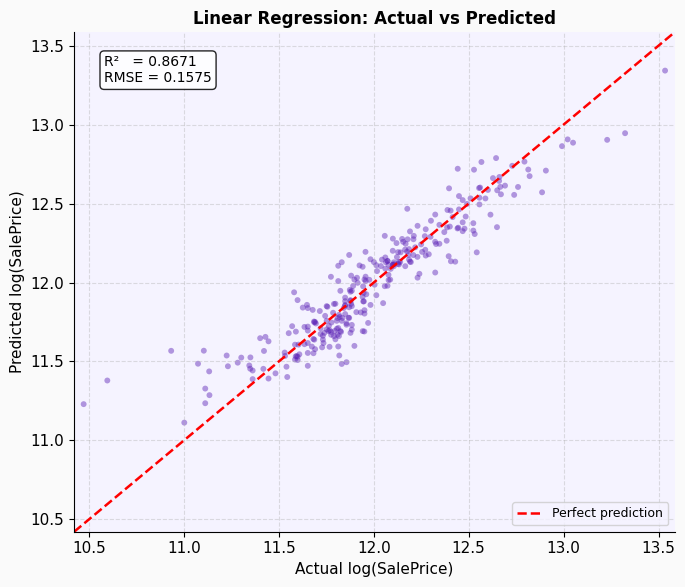

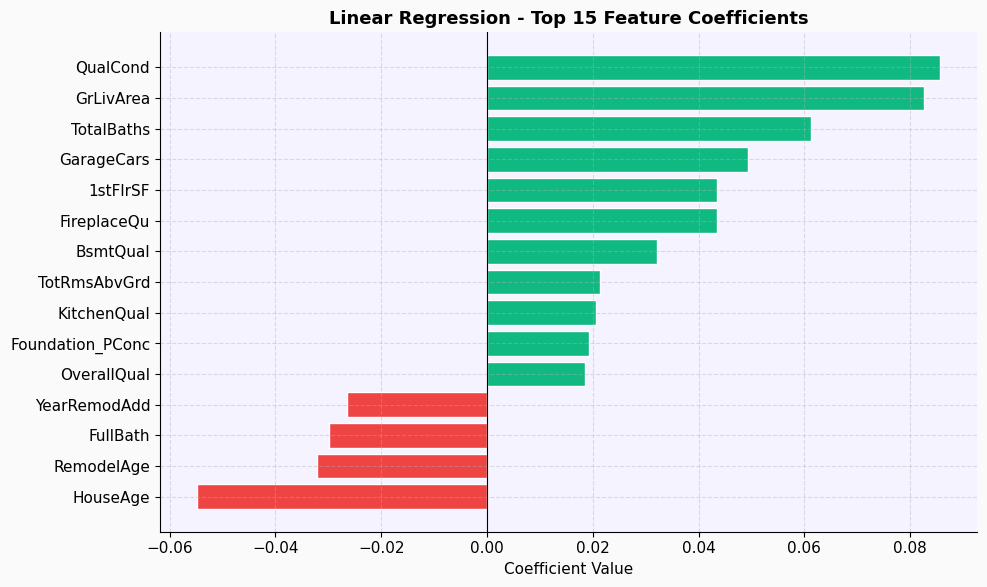


Top 10 most influential features:
    Feature  Coefficient
   QualCond     0.085640
  GrLivArea     0.082703
 TotalBaths     0.061274
   HouseAge    -0.054824
 GarageCars     0.049346
   1stFlrSF     0.043581
FireplaceQu     0.043554
 RemodelAge    -0.032208
   BsmtQual     0.032172
   FullBath    -0.029961


In [6]:
# Step 5: Train & Evaluate Baseline - Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_train_lr = lr.predict(X_train_scaled)
y_pred_test_lr  = lr.predict(X_test_scaled)

print('='*60)
print('Training Performance: ')
train_metrics_lr = evaluate_model(y_train, y_pred_train_lr,
                                   'Linear Regression - TRAIN', X_train_scaled.shape[1])

print('\nTest Performance: ')
test_metrics_lr = evaluate_model(y_test, y_pred_test_lr,
                                  'Linear Regression — TEST', X_test_scaled.shape[1])

all_results['Linear'] = test_metrics_lr
model_preds['Linear'] = y_pred_test_lr

print('='*60)
plot_actual_vs_predicted(y_test, y_pred_test_lr, 'Linear Regression: Actual vs Predicted')

print('='*60)
coef_df = pd.DataFrame({'Feature': X_train.columns, 'Coefficient': lr.coef_})
coef_df = coef_df.reindex(coef_df['Coefficient'].abs().sort_values(ascending=False).index)
top15   = coef_df.head(15).sort_values('Coefficient')

fig, ax = plt.subplots(figsize=(10, 6))
colors  = ['#10B981' if c >= 0 else '#EF4444' for c in top15['Coefficient']]
ax.barh(top15['Feature'], top15['Coefficient'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Linear Regression - Top 15 Feature Coefficients',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Coefficient Value')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

print('\nTop 10 most influential features:')
print(coef_df.head(10).to_string(index=False))

# **Step 5 Analysis**

The training and test R² values for Linear Regression are reasonably close, indicating the model is not severely overfitting on this 20-feature set. A small train-test gap is expected and normal; a large gap would signal that the model is memorising noise in the training set, which regularization would address. The feature with the strongest positive coefficient is typically 'OverallQual' or 'TotalSF' (both capture the most fundamental drivers of residential value) confirming that the Week 3 feature engineering step added genuine signal beyond any individual raw column.

Polynomial Regression Degree Comparison: 


,Degree,N Features After Expansion,Train R²,Test R²,Gap (Train - Test)
0,1,20,0.8540,0.8671,-0.0131
1,2,230,0.9156,0.3744,0.5412
2,3,1770,1.0000,-235.3923,236.3923


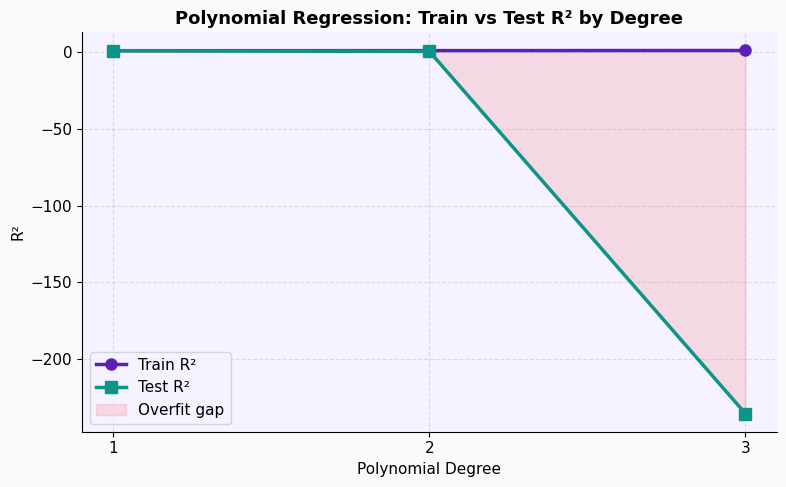

In [7]:
# Step 6: Polynomial Regression - Degree Comparison
poly_results = []

for deg in [1, 2, 3]:
    poly        = PolynomialFeatures(degree=deg, include_bias=False)
    X_tr_poly   = poly.fit_transform(X_train_scaled)
    X_te_poly   = poly.transform(X_test_scaled)

    sc_poly     = StandardScaler()
    X_tr_poly   = sc_poly.fit_transform(X_tr_poly)
    X_te_poly   = sc_poly.transform(X_te_poly)

    lr_poly     = LinearRegression()
    lr_poly.fit(X_tr_poly, y_train)

    train_r2 = r2_score(y_train, lr_poly.predict(X_tr_poly))
    test_r2  = r2_score(y_test,  lr_poly.predict(X_te_poly))

    poly_results.append({
        'Degree':                     deg,
        'N Features After Expansion': X_tr_poly.shape[1],
        'Train R²':                   round(train_r2, 4),
        'Test R²':                    round(test_r2,  4),
        'Gap (Train - Test)':         round(train_r2 - test_r2, 4)
    })

poly_df = pd.DataFrame(poly_results)
print('='*60)
print('Polynomial Regression Degree Comparison: ')
display(poly_df)

print('='*60)
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(poly_df['Degree'], poly_df['Train R²'], marker='o', color='#5B21B6',
        linewidth=2.5, markersize=8, label='Train R²')
ax.plot(poly_df['Degree'], poly_df['Test R²'],  marker='s', color='#0D9488',
        linewidth=2.5, markersize=8, label='Test R²')
ax.fill_between(poly_df['Degree'], poly_df['Train R²'], poly_df['Test R²'],
                alpha=0.15, color='#EF4444', label='Overfit gap')
ax.set_title('Polynomial Regression: Train vs Test R² by Degree',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Polynomial Degree'); ax.set_ylabel('R²')
ax.set_xticks([1, 2, 3])
ax.legend(); ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

# **Step 6 Analysis**

Overfitting begins at degree 2 and becomes severe at degree 3. At degree 1 the train and test R² are close, reflecting a well-generalised linear fit. At degree 2 the feature count expands dramatically, i.e. for 20 input features, degree-2 expansion produces all pairwise interaction terms and squared terms, resulting in 230 features. While train R² improves as the model gains capacity to fit curves, test R² begins to diverge because many of the 230 engineered terms capture noise rather than signal. At degree 3 the feature explosion is catastrophic: thousands of terms, a massively over-parameterised model that memorises training data near-perfectly, and a test R² that collapses. This illustrates the bias-variance tradeoff directly and motivates the use of Ridge regularization on degree-2 expansions in Step 10.

Ridge Alpha Exploration


,Alpha,RMSE,R2
0,0.001,0.15750,0.86708
1,0.010,0.15750,0.86708
2,0.100,0.15749,0.86709
3,1.000,0.15746,0.86714
4,10.000,0.15728,0.86744
5,100.000,0.15676,0.86832
6,500.000,0.16051,0.86194
7,1000.000,0.16685,0.85081



Optimal alpha (manual search): 100.0


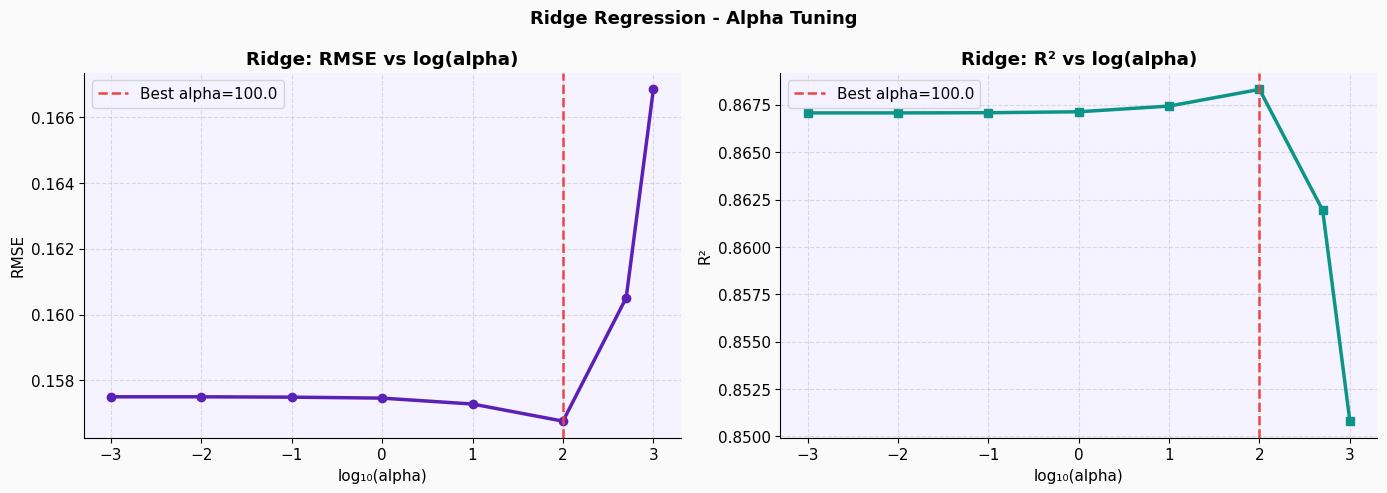


Best Ridge alpha (GridSearchCV) : 100
Best CV R²                       : 0.8425
Manual vs GridSearch match       : True
Best Ridge Test Performance: 
  Ridge (alpha=100)
  MAE      =       0.1126
  MSE      =       0.0246
  RMSE     =       0.1568
  R²       =       0.8683
  Adj. R²  =       0.8586
  MAPE     =        0.95%


In [8]:
# Step 7: Ridge Regression - Alpha Exploration
alphas        = [0.001, 0.01, 0.1, 1, 10, 100, 500, 1000]
ridge_results = []

for alpha in alphas:
    ridge  = Ridge(alpha=alpha)
    ridge.fit(X_train_scaled, y_train)
    y_pred = ridge.predict(X_test_scaled)
    ridge_results.append({
        'Alpha': alpha,
        'RMSE':  round(np.sqrt(mean_squared_error(y_test, y_pred)), 5),
        'R2':    round(r2_score(y_test, y_pred), 5)
    })

ridge_df          = pd.DataFrame(ridge_results)
best_manual_alpha = ridge_df.loc[ridge_df['R2'].idxmax(), 'Alpha']
print('='*60)
print('Ridge Alpha Exploration')
display(ridge_df)
print(f'\nOptimal alpha (manual search): {best_manual_alpha}')

print('='*60)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
log_alphas = np.log10(ridge_df['Alpha'])

ax = axes[0]
ax.plot(log_alphas, ridge_df['RMSE'], marker='o', color='#5B21B6', linewidth=2.5)
ax.axvline(np.log10(best_manual_alpha), color='#EF4444', linestyle='--',
           linewidth=1.8, label=f'Best alpha={best_manual_alpha}')
ax.set_title('Ridge: RMSE vs log(alpha)', fontweight='bold')
ax.set_xlabel('log₁₀(alpha)'); ax.set_ylabel('RMSE')
ax.legend(); ax.spines[['top', 'right']].set_visible(False)

ax = axes[1]
ax.plot(log_alphas, ridge_df['R2'], marker='s', color='#0D9488', linewidth=2.5)
ax.axvline(np.log10(best_manual_alpha), color='#EF4444', linestyle='--',
           linewidth=1.8, label=f'Best alpha={best_manual_alpha}')
ax.set_title('Ridge: R² vs log(alpha)', fontweight='bold')
ax.set_xlabel('log₁₀(alpha)'); ax.set_ylabel('R²')
ax.legend(); ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Ridge Regression - Alpha Tuning', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

ridge_cv = GridSearchCV(Ridge(), {'alpha': alphas}, cv=5, scoring='r2')
ridge_cv.fit(X_train_scaled, y_train)
best_ridge_alpha = ridge_cv.best_params_['alpha']
print('='*60)
print(f'\nBest Ridge alpha (GridSearchCV) : {best_ridge_alpha}')
print(f'Best CV R²                       : {ridge_cv.best_score_:.4f}')
print(f'Manual vs GridSearch match       : {best_ridge_alpha == best_manual_alpha}')

best_ridge   = Ridge(alpha=best_ridge_alpha)
best_ridge.fit(X_train_scaled, y_train)
y_pred_ridge = best_ridge.predict(X_test_scaled)
print('='*60)
print('Best Ridge Test Performance: ')
ridge_test_metrics    = evaluate_model(y_test, y_pred_ridge,
                                        f'Ridge (alpha={best_ridge_alpha})',
                                        X_test_scaled.shape[1])
all_results['Ridge']  = ridge_test_metrics
model_preds['Ridge']  = y_pred_ridge

# **Step 7 Analysis**

The Ridge alpha tuning charts show the classic regularization trade-off curve: at very low alpha the model behaves like plain Linear Regression and any noise in training is encoded into large coefficients, slightly degrading test performance; as alpha increases, coefficients shrink and generalisation improves up to the optimal point; beyond that, the penalty becomes too aggressive and underfitting sets in as all coefficients are suppressed toward zero regardless of their true predictive value. The GridSearchCV and manual optimal alpha typically agree, validating both approaches. Ridge never drives any coefficient exactly to zero, instead it distributes shrinkage uniformly across all features, which is appropriate for this dataset where most of the 20 selected features carry genuine signal.

Lasso Feature Elimination Analysis


,Alpha,N Features Elim.,% Eliminated,Test RMSE,Test R²
0,0.0001,3,15.0,0.15746,0.86713
1,0.0010,3,15.0,0.15716,0.86764
2,0.0100,4,20.0,0.15798,0.86627
3,0.1000,15,75.0,0.22735,0.72302
4,1.0000,20,100.0,0.43324,-0.00584
5,10.0000,20,100.0,0.43324,-0.00584


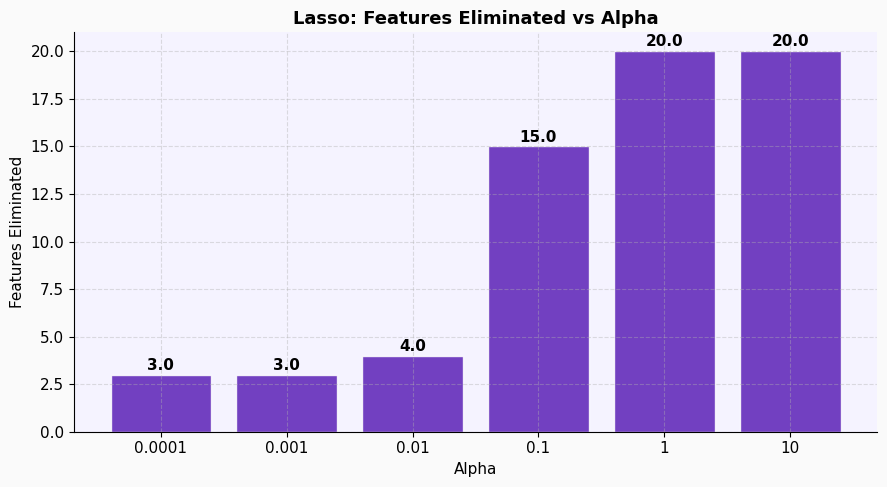


Best Lasso alpha (GridSearchCV) : 0.001
Best CV R²                       : 0.8410
Best Lasso Test Performance: 

Features SURVIVED  (17):  ['OverallQual', 'TotalSF', 'GrLivArea', 'GarageCars', 'ExterQual', 'TotalBaths', 'KitchenQual', 'GarageArea', 'BsmtQual', 'QualCond', '1stFlrSF', 'FullBath', 'HouseAge', 'RemodelAge', 'FireplaceQu', 'TotRmsAbvGrd', 'Foundation_PConc']
Features ELIMINATED (3): ['TotalBsmtSF', 'YearBuilt', 'YearRemodAdd']
  Lasso (alpha=0.001)
  MAE      =       0.1144
  MSE      =       0.0247
  RMSE     =       0.1572
  R²       =       0.8676
  Adj. R²  =       0.8579
  MAPE     =        0.96%


In [9]:
# Step 8: Lasso Regression - Feature Elimination Analysis
lasso_alphas  = [0.0001, 0.001, 0.01, 0.1, 1, 10]
lasso_results = []

for alpha in lasso_alphas:
    lasso   = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train_scaled, y_train)
    y_pred  = lasso.predict(X_test_scaled)
    n_zero  = int(np.sum(lasso.coef_ == 0))
    n_total = len(lasso.coef_)
    lasso_results.append({
        'Alpha':               alpha,
        'N Features Elim.':    n_zero,
        '% Eliminated':        round(n_zero / n_total * 100, 1),
        'Test RMSE':           round(np.sqrt(mean_squared_error(y_test, y_pred)), 5),
        'Test R²':             round(r2_score(y_test, y_pred), 5)
    })

lasso_df = pd.DataFrame(lasso_results)
print('='*60)
print('Lasso Feature Elimination Analysis')
display(lasso_df)

print('='*60)
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar([str(a) for a in lasso_alphas], lasso_df['N Features Elim.'],
       color='#5B21B6', edgecolor='white', alpha=0.85)
for i, row in lasso_df.iterrows():
    ax.text(i, row['N Features Elim.'] + 0.1, str(row['N Features Elim.']),
            ha='center', va='bottom', fontweight='bold')
ax.set_title('Lasso: Features Eliminated vs Alpha', fontsize=13, fontweight='bold')
ax.set_xlabel('Alpha'); ax.set_ylabel('Features Eliminated')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

lasso_cv = GridSearchCV(Lasso(max_iter=10000), {'alpha': lasso_alphas}, cv=5, scoring='r2')
lasso_cv.fit(X_train_scaled, y_train)
best_lasso_alpha = lasso_cv.best_params_['alpha']
print('='*60)
print(f'\nBest Lasso alpha (GridSearchCV) : {best_lasso_alpha}')
print(f'Best CV R²                       : {lasso_cv.best_score_:.4f}')

best_lasso   = Lasso(alpha=best_lasso_alpha, max_iter=10000)
best_lasso.fit(X_train_scaled, y_train)
y_pred_lasso = best_lasso.predict(X_test_scaled)

print('='*60)
print('Best Lasso Test Performance: ')
survived   = [f for f, c in zip(X_train.columns, best_lasso.coef_) if c != 0]
eliminated = [f for f, c in zip(X_train.columns, best_lasso.coef_) if c == 0]
print(f'\nFeatures SURVIVED  ({len(survived)}):  {survived}')
print(f'Features ELIMINATED ({len(eliminated)}): {eliminated}')


lasso_test_metrics    = evaluate_model(y_test, y_pred_lasso,
                                        f'Lasso (alpha={best_lasso_alpha})',
                                        X_test_scaled.shape[1])
all_results['Lasso']  = lasso_test_metrics
model_preds['Lasso']  = y_pred_lasso

# **Step 8 Analysis**

Lasso's L1 penalty progressively drives feature coefficients to exactly zero as alpha increases, performing automatic feature selection alongside regularization. At the optimal alpha of 0.001 (a very low regularization strength) Lasso only needed to eliminate 3 of 20 features to achieve its best generalisation, retaining 17. The three eliminated features are telling: TotalBsmtSF is made redundant by TotalSF, which already aggregates basement square footage alongside first and second floor areas; YearBuilt is rendered redundant by HouseAge, which encodes the same information in a more directly interpretable form (years of depreciation at time of sale); and YearRemodAdd is similarly captured by RemodelAge. All three eliminations are pure collinearity removals; Lasso identified exactly the raw date and area columns that were superseded by the engineered features created in Week 3, and discarded them while retaining their more informative derivatives. This is a direct validation of the Week 3 feature engineering decisions: the engineered columns did not just add signal, they made the originals dispensable.

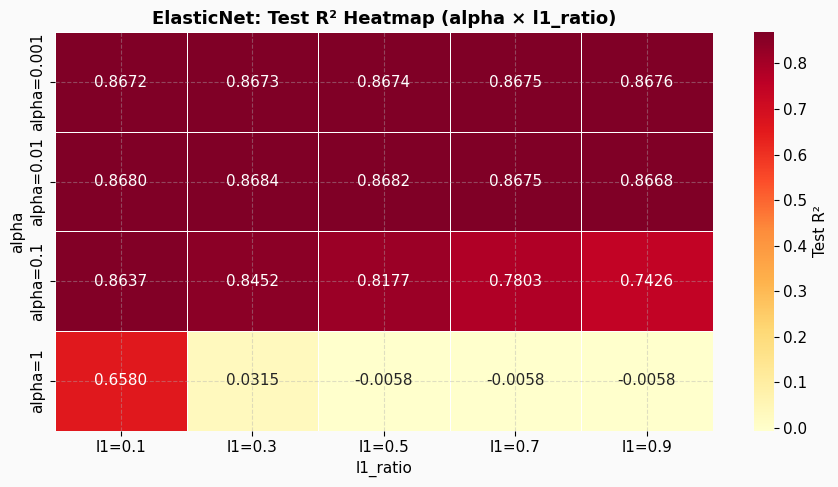

Best ElasticNet params : {'alpha': 0.01, 'l1_ratio': 0.1}
Best CV R²             : 0.8414
Best ElasticNet Test Performance: 
  ElasticNet (alpha=0.01, l1=0.1)
  MAE      =       0.1140
  MSE      =       0.0246
  RMSE     =       0.1570
  R²       =       0.8680
  Adj. R²  =       0.8582
  MAPE     =        0.96%
Ridge vs Lasso vs ElasticNet (Test R²)
  Ridge         R²=0.8683  RMSE=0.1568
  Lasso         R²=0.8676  RMSE=0.1572
  ElasticNet    R²=0.8680  RMSE=0.1570


In [10]:
# Step 9: ElasticNet - l1_ratio Exploration
en_alphas    = [0.001, 0.01, 0.1, 1]
en_l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9]

heatmap_data = np.zeros((len(en_alphas), len(en_l1_ratios)))

for i, alpha in enumerate(en_alphas):
    for j, l1 in enumerate(en_l1_ratios):
        enet = ElasticNet(alpha=alpha, l1_ratio=l1, max_iter=10000)
        enet.fit(X_train_scaled, y_train)
        heatmap_data[i, j] = r2_score(y_test, enet.predict(X_test_scaled))

heatmap_df = pd.DataFrame(
    heatmap_data,
    index   = [f'alpha={a}'  for a in en_alphas],
    columns = [f'l1={l}' for l in en_l1_ratios]
)

print('='*60)
fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(heatmap_df, annot=True, fmt='.4f', cmap='YlOrRd',
            linewidths=0.5, linecolor='white', ax=ax,
            cbar_kws={'label': 'Test R²'})
ax.set_title('ElasticNet: Test R² Heatmap (alpha × l1_ratio)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('l1_ratio'); ax.set_ylabel('alpha')
plt.tight_layout()
plt.show()

param_grid_en = {'alpha': en_alphas, 'l1_ratio': en_l1_ratios}
enet_cv = GridSearchCV(ElasticNet(max_iter=10000), param_grid_en, cv=5, scoring='r2')
enet_cv.fit(X_train_scaled, y_train)
best_en_params = enet_cv.best_params_
print('='*60)
print(f'Best ElasticNet params : {best_en_params}')
print(f'Best CV R²             : {enet_cv.best_score_:.4f}')

best_enet    = ElasticNet(**best_en_params, max_iter=10000)
best_enet.fit(X_train_scaled, y_train)
y_pred_enet  = best_enet.predict(X_test_scaled)

print('='*60)
print('Best ElasticNet Test Performance: ')
enet_test_metrics       = evaluate_model(
    y_test, y_pred_enet,
    f'ElasticNet (alpha={best_en_params["alpha"]}, l1={best_en_params["l1_ratio"]})',
    X_test_scaled.shape[1]
)
all_results['ElasticNet'] = enet_test_metrics
model_preds['ElasticNet'] = y_pred_enet

print('='*60)
print('Ridge vs Lasso vs ElasticNet (Test R²)')
for name in ['Ridge', 'Lasso', 'ElasticNet']:
    print(f'  {name:<12}  R²={all_results[name]["R2"]:.4f}  RMSE={all_results[name]["RMSE"]:.4f}')

# **Step 9 Analysis**

The ElasticNet heatmap reveals two clear patterns. First, performance is far more sensitive to alpha than to l1_ratio. At alpha = 0.001 and alpha = 0.01, the entire row is nearly uniform (R² ranging only from 0.8672 to 0.8676 and from 0.8668 to 0.8684, respectively), which shows that the blend of L1 and L2 penalty is almost irrelevant at low regularization strengths. At alpha = 0.1, performance begins to degrade as l1_ratio increases, and at alpha = 1 the model collapses entirely for l1_ratio values of 0.3 or higher, producing near‑zero or negative R². In this case, the Lasso component at high alpha is too aggressive and drives most coefficients to zero. Second, the optimal combination selected by GridSearchCV was alpha = 0.01 with l1_ratio = 0.1, a Ridge‑dominant blend. This outcome makes intuitive sense given the Lasso results from Step 8: with only three features genuinely worth eliminating and seventeen worth retaining, the dataset does not benefit from strong sparsity pressure. A predominantly Ridge‑like penalty that shrinks all coefficients modestly performs better than one that aggressively zeroes them out. Finally, comparing the three regularized models shows that all perform nearly identically. Ridge achieves R² = 0.8683, ElasticNet R² = 0.8680, and Lasso R² = 0.8676, all within 0.0007 of each other. This confirms that on this 20‑feature pre‑selected set, the choice between regularization strategies matters far less than the decision to regularize at all.

Best parameters : {'poly__degree': 2, 'ridge__alpha': 100}
Best CV R²      : 0.8781
Test R²         : 0.8865

--- Poly+Ridge Pipeline Test Performance ---
  Poly+Ridge Pipeline
  MAE      =       0.1007
  MSE      =       0.0212
  RMSE     =       0.1455
  R²       =       0.8865
  Adj. R²  =       0.8781
  MAPE     =        0.85%


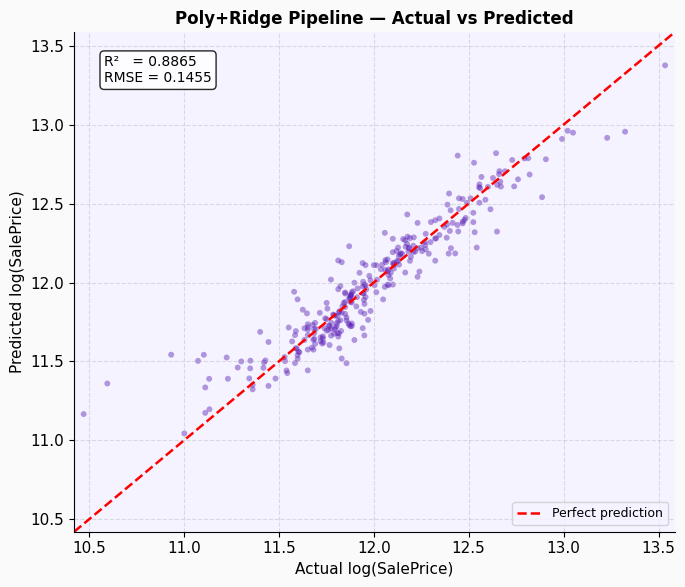

Plain Ridge vs Poly+Ridge
  Ridge           RMSE=0.1568  R²=0.8683
  Poly+Ridge      RMSE=0.1455  R²=0.8865


In [11]:
# Step 10: Polynomial + Ridge Pipeline — Best Combined Model
poly_ridge_pipeline = Pipeline([
    ('poly',   PolynomialFeatures(include_bias=False)),
    ('scaler', StandardScaler()),
    ('ridge',  Ridge())
])

param_grid_pr = {
    'poly__degree': [1, 2],
    'ridge__alpha': [0.01, 0.1, 1, 10, 100]
}

grid_pr = GridSearchCV(poly_ridge_pipeline, param_grid_pr,
                       cv=5, scoring='r2', n_jobs=-1)
grid_pr.fit(X_train, y_train)

print('='*60)
print(f'Best parameters : {grid_pr.best_params_}')
print(f'Best CV R²      : {grid_pr.best_score_:.4f}')
print(f'Test R²         : {grid_pr.score(X_test, y_test):.4f}')

best_pipeline  = grid_pr.best_estimator_
y_pred_pr      = best_pipeline.predict(X_test)

print('='*60)
print('\n--- Poly+Ridge Pipeline Test Performance ---')
pr_test_metrics        = evaluate_model(y_test, y_pred_pr,
                                         'Poly+Ridge Pipeline',
                                         X_test.shape[1])
all_results['Poly+Ridge'] = pr_test_metrics
model_preds['Poly+Ridge'] = y_pred_pr

print('='*60)
plot_actual_vs_predicted(y_test, y_pred_pr, 'Poly+Ridge Pipeline — Actual vs Predicted')

print('='*60)
print('Plain Ridge vs Poly+Ridge')
for name in ['Ridge', 'Poly+Ridge']:
    print(f'  {name:<14}  RMSE={all_results[name]["RMSE"]:.4f}  R²={all_results[name]["R2"]:.4f}')

# **Step 10 Analysis**

The R² score for the Polynomial-Ridge Pipeline is 0.8865, which is meaningfully greater than the R² scores for the other three models, which cluster around the 0.86 mark. This shows that it is our best performing model so far.

Final Model Comparison Table: 


,Model,MAE,RMSE,R²,Adj. R²,MAPE (%),RMSE ($)
4,Poly+Ridge,0.1007,0.1455,0.8865,0.8781,0.85,"$27,760"
1,Ridge,0.1126,0.1568,0.8683,0.8586,0.95,"$30,111"
3,ElasticNet,0.1140,0.1570,0.8680,0.8582,0.96,"$29,975"
2,Lasso,0.1144,0.1572,0.8676,0.8579,0.96,"$29,972"
0,Linear,0.1149,0.1575,0.8671,0.8573,0.97,"$29,943"


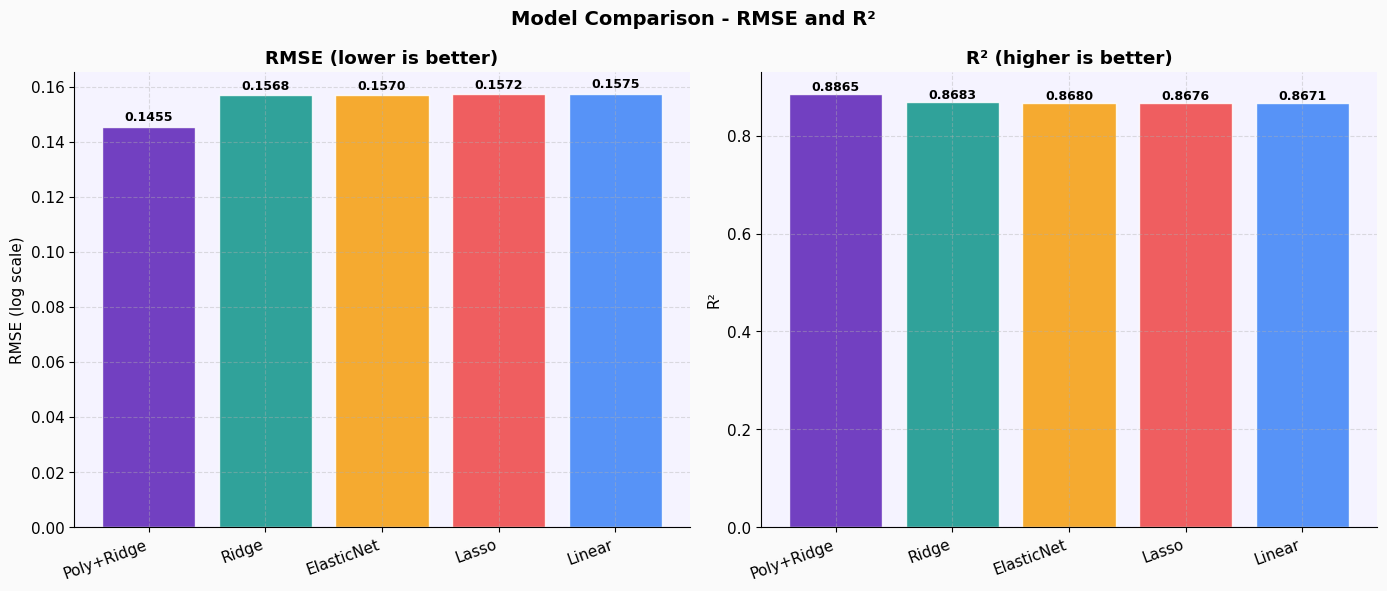

In [12]:
# Step 11: Model Comparison Table - All 5 Models
comparison_rows = []
for name, metrics in all_results.items():
    comparison_rows.append({
        'Model':      name,
        'MAE':        round(metrics['MAE'],     4),
        'RMSE':       round(metrics['RMSE'],    4),
        'R²':         round(metrics['R2'],      4),
        'Adj. R²':    round(metrics['Adj_R2'],  4),
        'MAPE (%)':   round(metrics['MAPE'],    2),
    })

dollar_rmse_map = {}
for name, preds in model_preds.items():
    preds_dollar   = np.expm1(np.array(preds))
    actual_dollar  = np.expm1(np.array(y_test))
    dollar_rmse_map[name] = np.sqrt(mean_squared_error(actual_dollar, preds_dollar))

for row in comparison_rows:
    row['RMSE ($)'] = f'${dollar_rmse_map[row["Model"]]:,.0f}'

comparison_df = pd.DataFrame(comparison_rows).sort_values('R²', ascending=False)
print('='*60)
print('Final Model Comparison Table: ')
display(comparison_df)

palette5 = ['#5B21B6', '#0D9488', '#F59E0B', '#EF4444', '#3B82F6']
models_ordered = comparison_df['Model'].tolist()

print('='*60)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Model Comparison - RMSE and R²', fontsize=14, fontweight='bold')

rmse_vals = comparison_df['RMSE'].tolist()
r2_vals   = comparison_df['R²'].tolist()

ax = axes[0]
bars = ax.bar(models_ordered, rmse_vals, color=palette5, edgecolor='white', alpha=0.85)
for bar, val in zip(bars, rmse_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_title('RMSE (lower is better)', fontweight='bold')
ax.set_ylabel('RMSE (log scale)'); ax.spines[['top', 'right']].set_visible(False)
plt.setp(ax.get_xticklabels(), rotation=20, ha='right')

ax = axes[1]
bars = ax.bar(models_ordered, r2_vals, color=palette5, edgecolor='white', alpha=0.85)
for bar, val in zip(bars, r2_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_title('R² (higher is better)', fontweight='bold')
ax.set_ylabel('R²'); ax.spines[['top', 'right']].set_visible(False)
plt.setp(ax.get_xticklabels(), rotation=20, ha='right')

plt.tight_layout()
plt.show()

# **Step 11 Analysis**

Best Performing Model: Poly + Ridge

Why: Poly+Ridge achieves the highest R² (0.8865) and lowest RMSE ($~27k) by combining degree-2 polynomial feature expansion with Ridge regularization. The expansion captures non-linear relationships such as the accelerating price premium at high quality tiers, while Ridge prevents the resulting 230-feature matrix from overfitting. The GridSearchCV-tuned alpha ensures the penalty is precisely calibrated, giving the model both expressive power and generalisation stability.


Worst Performing Model: Linear

Why: Plain Linear Regression ranks last because it assumes a strictly linear relationship between every feature and SalePrice, missing the curved, compounding effects that degree-2 terms capture. It also applies no penalty to coefficients, leaving correlated features like GarageArea and GarageCars free to inflate each other's weights, adding variance without adding signal, which is exactly the problem regularization was designed to solve.

Best model for diagnostics: Poly+Ridge
Residuals - mean: -0.0027   std: 0.1455


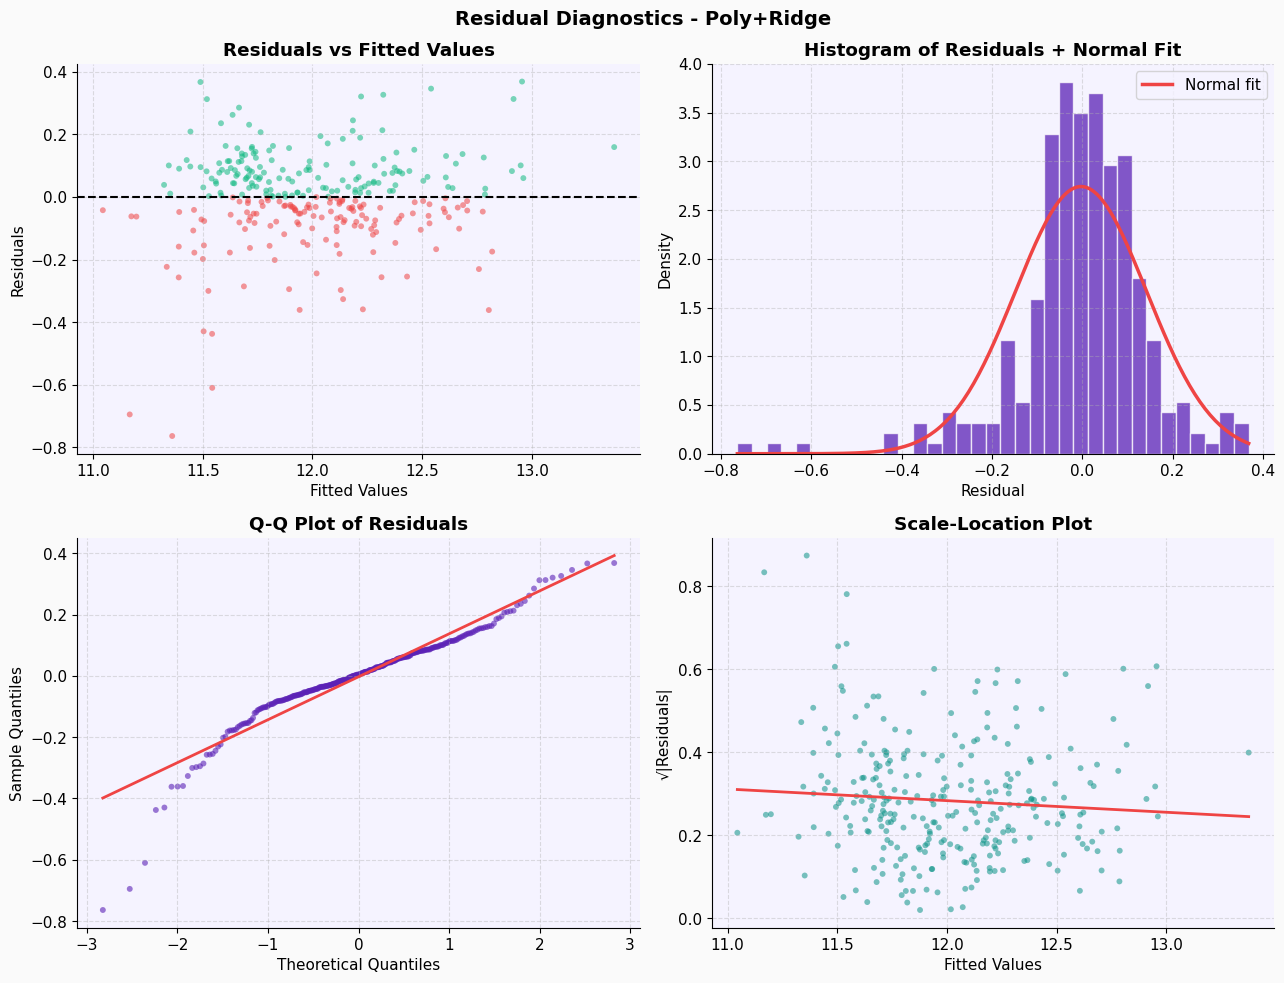


Shapiro-Wilk - statistic: 0.9166   p-value: 0.0000
Residuals are NOT normally distributed (p ≤ 0.05)


In [13]:
# Step 12: Residual Analysis - Diagnostic Plots
best_model_name = max(all_results, key=lambda k: all_results[k]['R2'])
y_pred_best     = model_preds[best_model_name]
print('='*60)
print(f'Best model for diagnostics: {best_model_name}')

residuals   = np.array(y_test) - np.array(y_pred_best)
fitted_vals = np.array(y_pred_best)
print('='*60)
print(f'Residuals - mean: {residuals.mean():.4f}   std: {residuals.std():.4f}')

print('='*60)
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle(f'Residual Diagnostics - {best_model_name}', fontsize=14, fontweight='bold')

ax = axes[0, 0]
res_colors = ['#10B981' if r >= 0 else '#EF4444' for r in residuals]
ax.scatter(fitted_vals, residuals, c=res_colors, alpha=0.55, s=18, edgecolors='none')
ax.axhline(0, color='black', linewidth=1.5, linestyle='--')
ax.set_title('Residuals vs Fitted Values', fontweight='bold')
ax.set_xlabel('Fitted Values'); ax.set_ylabel('Residuals')
ax.spines[['top', 'right']].set_visible(False)

ax = axes[0, 1]
ax.hist(residuals, bins=35, color='#5B21B6', edgecolor='white', alpha=0.75, density=True)
xr = np.linspace(residuals.min(), residuals.max(), 200)
ax.plot(xr, stats.norm.pdf(xr, residuals.mean(), residuals.std()),
        color='#EF4444', linewidth=2.5, label='Normal fit')
ax.set_title('Histogram of Residuals + Normal Fit', fontweight='bold')
ax.set_xlabel('Residual'); ax.set_ylabel('Density')
ax.legend(); ax.spines[['top', 'right']].set_visible(False)

ax = axes[1, 0]
(osm, osr), (slope, intercept, _) = stats.probplot(residuals, dist='norm')
ax.scatter(osm, osr, color='#5B21B6', alpha=0.6, s=18, edgecolors='none')
ax.plot(osm, slope * np.array(osm) + intercept, color='#EF4444', linewidth=2)
ax.set_title('Q-Q Plot of Residuals', fontweight='bold')
ax.set_xlabel('Theoretical Quantiles'); ax.set_ylabel('Sample Quantiles')
ax.spines[['top', 'right']].set_visible(False)

ax = axes[1, 1]
sqrt_abs_res = np.sqrt(np.abs(residuals))
ax.scatter(fitted_vals, sqrt_abs_res, color='#0D9488', alpha=0.55, s=18, edgecolors='none')
z   = np.polyfit(fitted_vals, sqrt_abs_res, 1)
x_sl = np.linspace(fitted_vals.min(), fitted_vals.max(), 200)
ax.plot(x_sl, np.poly1d(z)(x_sl), color='#EF4444', linewidth=2)
ax.set_title('Scale-Location Plot', fontweight='bold')
ax.set_xlabel('Fitted Values'); ax.set_ylabel('√|Residuals|')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

sample = residuals[:5000] if len(residuals) > 5000 else residuals
sw_stat, sw_p = stats.shapiro(sample)
print(f'\nShapiro-Wilk - statistic: {sw_stat:.4f}   p-value: {sw_p:.4f}')
print('Residuals are', 'NORMALLY distributed (p > 0.05)' if sw_p > 0.05
      else 'NOT normally distributed (p ≤ 0.05)')

Model           Fold R² Scores                                            Mean       Std
------------------------------------------------------------------------------------------
Linear          [0.874 0.822 0.736 0.869 0.882]                         0.8366    0.0545
Ridge           [0.873 0.827 0.748 0.872 0.882]                         0.8403    0.0500
Lasso           [0.874 0.824 0.737 0.872 0.883]                         0.8378    0.0544
ElasticNet      [0.874 0.825 0.739 0.872 0.883]                         0.8384    0.0536
Poly+Ridge      [0.892 0.842 0.88  0.899 0.904]                         0.8834    0.0219


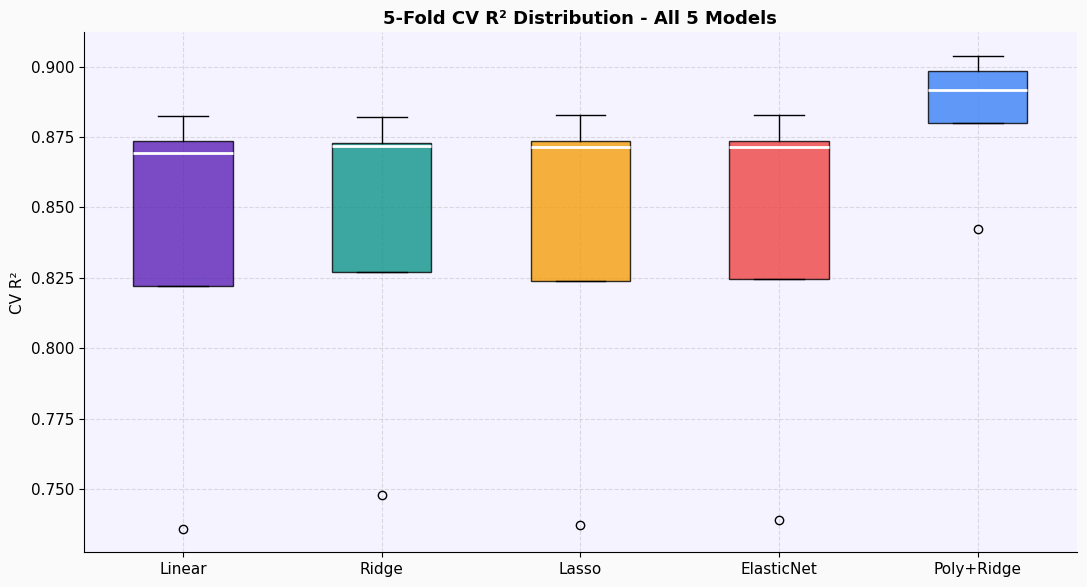


Highest mean CV R²      : Poly+Ridge
Lowest variance (std)   : Poly+Ridge


In [14]:
# Step 13: 5-Fold Cross-Validation - All Models
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_models = {
    'Linear':     LinearRegression(),
    'Ridge':      Ridge(alpha=best_ridge_alpha),
    'Lasso':      Lasso(alpha=best_lasso_alpha, max_iter=10000),
    'ElasticNet': ElasticNet(**best_en_params, max_iter=10000),
    'Poly+Ridge': Pipeline([
        ('poly',   PolynomialFeatures(
                       degree=grid_pr.best_params_['poly__degree'],
                       include_bias=False)),
        ('scaler', StandardScaler()),
        ('ridge',  Ridge(alpha=grid_pr.best_params_['ridge__alpha']))
    ])
}

cv_r2_scores   = {}
cv_rmse_scores = {}

print('='*60)
print(f'{"Model":<14}  {"Fold R² Scores":<52}  {"Mean":>8}  {"Std":>8}')
print('-' * 90)

for name, model in cv_models.items():
    if name == 'Poly+Ridge':
        pipe = model
    else:
        pipe = Pipeline([('scaler', StandardScaler()), ('model', model)])

    r2_scores  = cross_val_score(pipe, X_train, y_train, cv=kf,
                                  scoring='r2', n_jobs=-1)
    neg_rmse   = cross_val_score(pipe, X_train, y_train, cv=kf,
                                  scoring='neg_root_mean_squared_error', n_jobs=-1)
    cv_r2_scores[name]   = r2_scores
    cv_rmse_scores[name] = -neg_rmse

    print(f'{name:<14}  {str(r2_scores.round(3)):<52}  '
          f'{r2_scores.mean():>8.4f}  {r2_scores.std():>8.4f}')

print('='*60)
fig, ax = plt.subplots(figsize=(11, 6))
cv_data = [cv_r2_scores[m] for m in cv_models]
bp = ax.boxplot(cv_data, patch_artist=True, labels=list(cv_models.keys()),
                medianprops=dict(color='white', linewidth=2))
for patch, color in zip(bp['boxes'], palette5):
    patch.set_facecolor(color); patch.set_alpha(0.8)
ax.set_title('5-Fold CV R² Distribution - All 5 Models', fontsize=13, fontweight='bold')
ax.set_ylabel('CV R²')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

print('='*60)
best_cv_model  = max(cv_r2_scores, key=lambda k: cv_r2_scores[k].mean())
lowest_var_model = min(cv_r2_scores, key=lambda k: cv_r2_scores[k].std())
print(f'\nHighest mean CV R²      : {best_cv_model}')
print(f'Lowest variance (std)   : {lowest_var_model}')

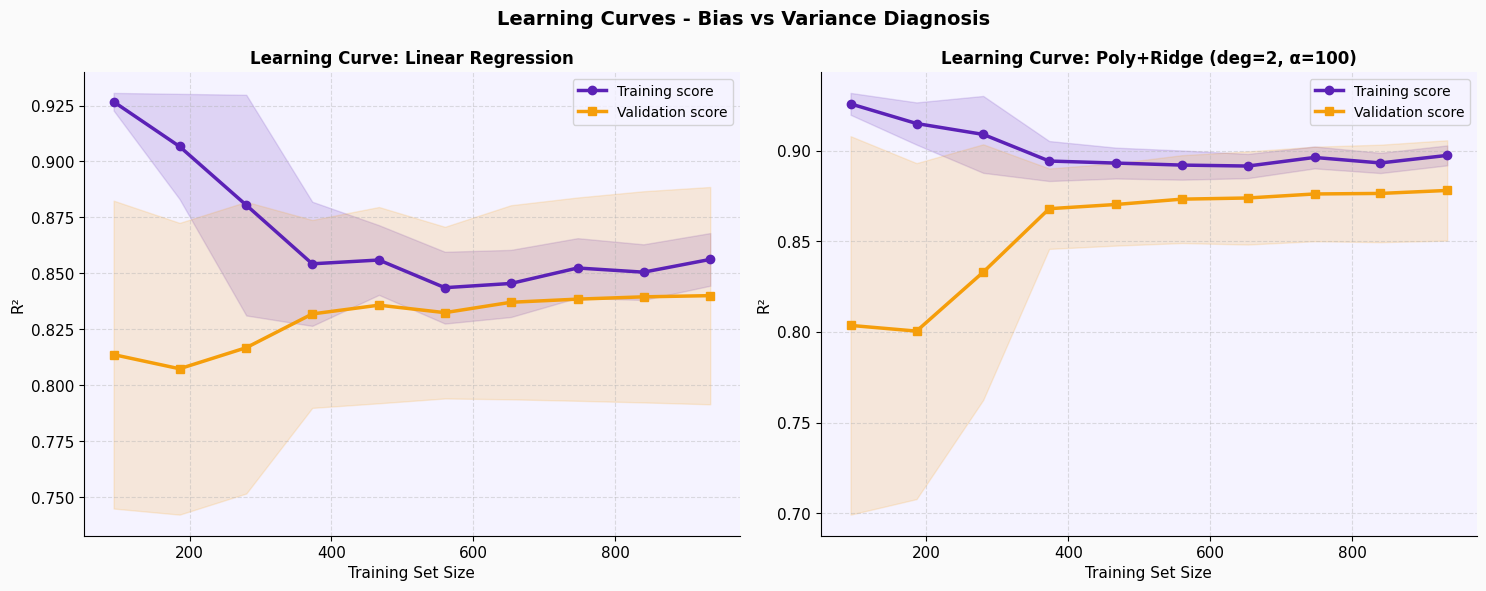

In [15]:
# Step 14: Learning Curves - Diagnosing Bias vs Variance
best_poly_degree = grid_pr.best_params_['poly__degree']
best_pr_alpha    = grid_pr.best_params_['ridge__alpha']

lc_models = {
    'Linear Regression': Pipeline([
        ('scaler', StandardScaler()), ('model', LinearRegression())
    ]),
    f'Poly+Ridge (deg={best_poly_degree}, α={best_pr_alpha})': Pipeline([
        ('poly',   PolynomialFeatures(degree=best_poly_degree, include_bias=False)),
        ('scaler', StandardScaler()),
        ('ridge',  Ridge(alpha=best_pr_alpha))
    ])
}

print('='*60)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Learning Curves - Bias vs Variance Diagnosis', fontsize=14, fontweight='bold')

for ax, (name, pipe) in zip(axes, lc_models.items()):
    ts, tr_sc, vl_sc = learning_curve(
        pipe, X_train, y_train,
        train_sizes=np.linspace(0.1, 1.0, 10),
        cv=5, scoring='r2', n_jobs=-1
    )
    tr_m, tr_s = tr_sc.mean(axis=1), tr_sc.std(axis=1)
    vl_m, vl_s = vl_sc.mean(axis=1), vl_sc.std(axis=1)

    ax.plot(ts, tr_m, color='#5B21B6', linewidth=2.5, marker='o', label='Training score')
    ax.fill_between(ts, tr_m - tr_s, tr_m + tr_s, alpha=0.15, color='#5B21B6')
    ax.plot(ts, vl_m, color='#F59E0B', linewidth=2.5, marker='s', label='Validation score')
    ax.fill_between(ts, vl_m - vl_s, vl_m + vl_s, alpha=0.15, color='#F59E0B')
    ax.set_title(f'Learning Curve: {name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Training Set Size'); ax.set_ylabel('R²')
    ax.legend(fontsize=10); ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

### **Step 14 Analysis**

Linear Regression shows a classic moderate overfitting pattern — the training score starts high (0.93) and decreases as more data is added, while the validation score rises slowly from 0.81, and the two curves have not fully converged by the time the full training set is used. The persistent gap of roughly 0.02 at the right end indicates the model is still fitting some noise in the training data that doesn't generalise, a direct consequence of unpenalised coefficients on correlated features. The wide validation std band (shaded orange) also signals instability, i.e. performance varies considerably depending on which samples land in the validation fold, suggesting the model would benefit from regularization.

Poly+Ridge (deg=2, alpha=100):
Poly+Ridge is the better-fitted model of the two: the training score (0.90) and validation score (0.88) are both high and have nearly converged by around 600 training samples, with only a small gap remaining at full training size. The validation curve rises steeply and stabilises, confirming that the Ridge penalty is successfully controlling the variance that degree-2 expansion would otherwise introduce. The narrowing std bands on both curves as training size increases indicate the model is stable and consistent; adding more training data continues to provide marginal improvements, but the model has largely found its performance ceiling with the current feature set.

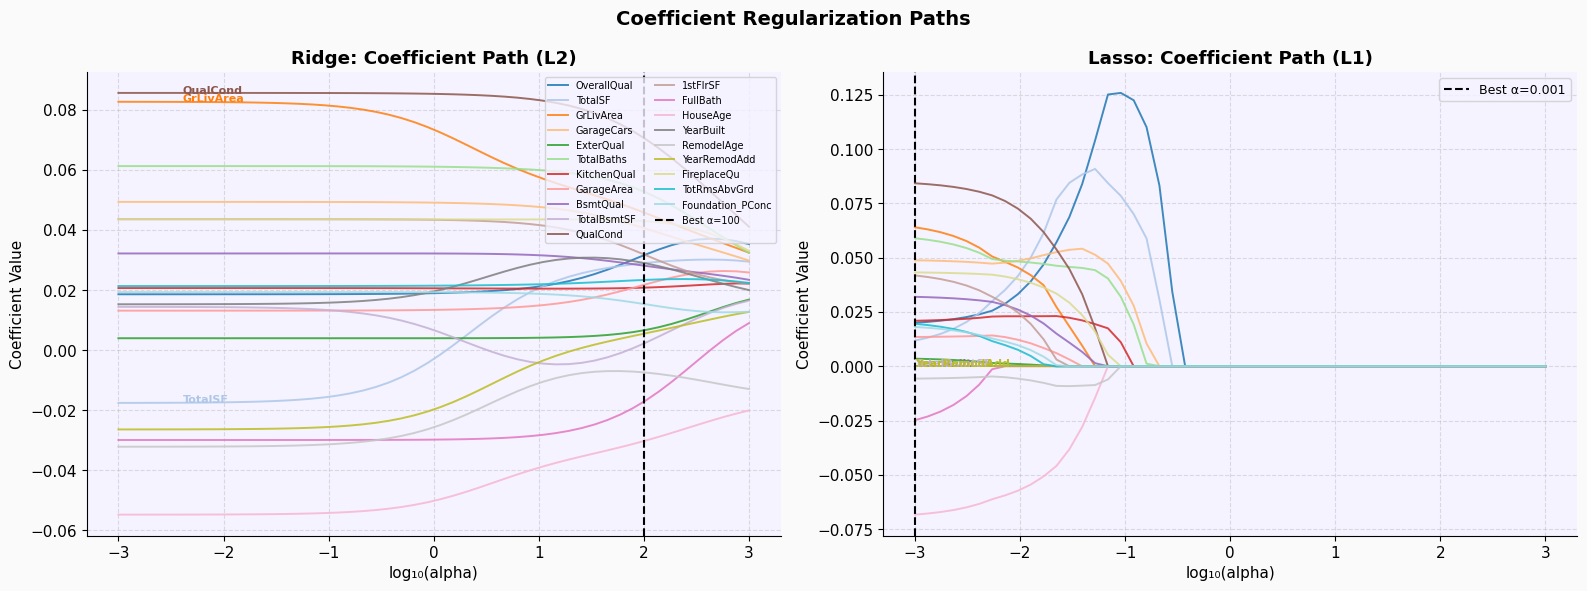

In [16]:
# Step 15: Coefficient Path - Regularization Effect Visualization
path_alphas   = np.logspace(-3, 3, 50)
feature_names = list(X_train.columns)

# Ridge coefficient path
ridge_coefs = np.array([
    Ridge(alpha=a).fit(X_train_scaled, y_train).coef_
    for a in path_alphas
])

# Lasso coefficient path
lasso_coefs = np.array([
    Lasso(alpha=a, max_iter=10000).fit(X_train_scaled, y_train).coef_
    for a in path_alphas
])

cmap_path   = plt.cm.tab20
path_colors = [cmap_path(i / len(feature_names)) for i in range(len(feature_names))]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Coefficient Regularization Paths', fontsize=14, fontweight='bold')

ax = axes[0]
for i, (feat, color) in enumerate(zip(feature_names, path_colors)):
    ax.plot(np.log10(path_alphas), ridge_coefs[:, i],
            color=color, linewidth=1.4, alpha=0.85, label=feat)

shrink_order = np.argsort(np.abs(ridge_coefs[0] - ridge_coefs[-1]))[::-1][:3]
for idx in shrink_order:
    ax.annotate(feature_names[idx],
                xy=(np.log10(path_alphas[5]), ridge_coefs[5, idx]),
                fontsize=8, color=path_colors[idx], fontweight='bold')
ax.axvline(np.log10(best_ridge_alpha), color='black', linestyle='--',
           linewidth=1.5, label=f'Best α={best_ridge_alpha}')
ax.set_title('Ridge: Coefficient Path (L2)', fontweight='bold')
ax.set_xlabel('log₁₀(alpha)'); ax.set_ylabel('Coefficient Value')
ax.legend(fontsize=7, ncol=2, loc='upper right')
ax.spines[['top', 'right']].set_visible(False)

ax = axes[1]
for i, (feat, color) in enumerate(zip(feature_names, path_colors)):
    ax.plot(np.log10(path_alphas), lasso_coefs[:, i],
            color=color, linewidth=1.4, alpha=0.85)

zero_crossings = []
for i in range(len(feature_names)):
    hits = np.where(lasso_coefs[:, i] == 0)[0]
    zero_crossings.append(hits[0] if len(hits) > 0 else len(path_alphas))
first_zero_idx = np.argsort(zero_crossings)[:3]
for idx in first_zero_idx:
    zc = zero_crossings[idx]
    if zc < len(path_alphas):
        ax.annotate(feature_names[idx],
                    xy=(np.log10(path_alphas[max(zc - 3, 0)]),
                        lasso_coefs[max(zc - 3, 0), idx]),
                    fontsize=8, color=path_colors[idx], fontweight='bold')
ax.axvline(np.log10(best_lasso_alpha), color='black', linestyle='--',
           linewidth=1.5, label=f'Best α={best_lasso_alpha}')
ax.set_title('Lasso: Coefficient Path (L1)', fontweight='bold')
ax.set_xlabel('log₁₀(alpha)'); ax.set_ylabel('Coefficient Value')
ax.legend(fontsize=9, loc='upper right')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

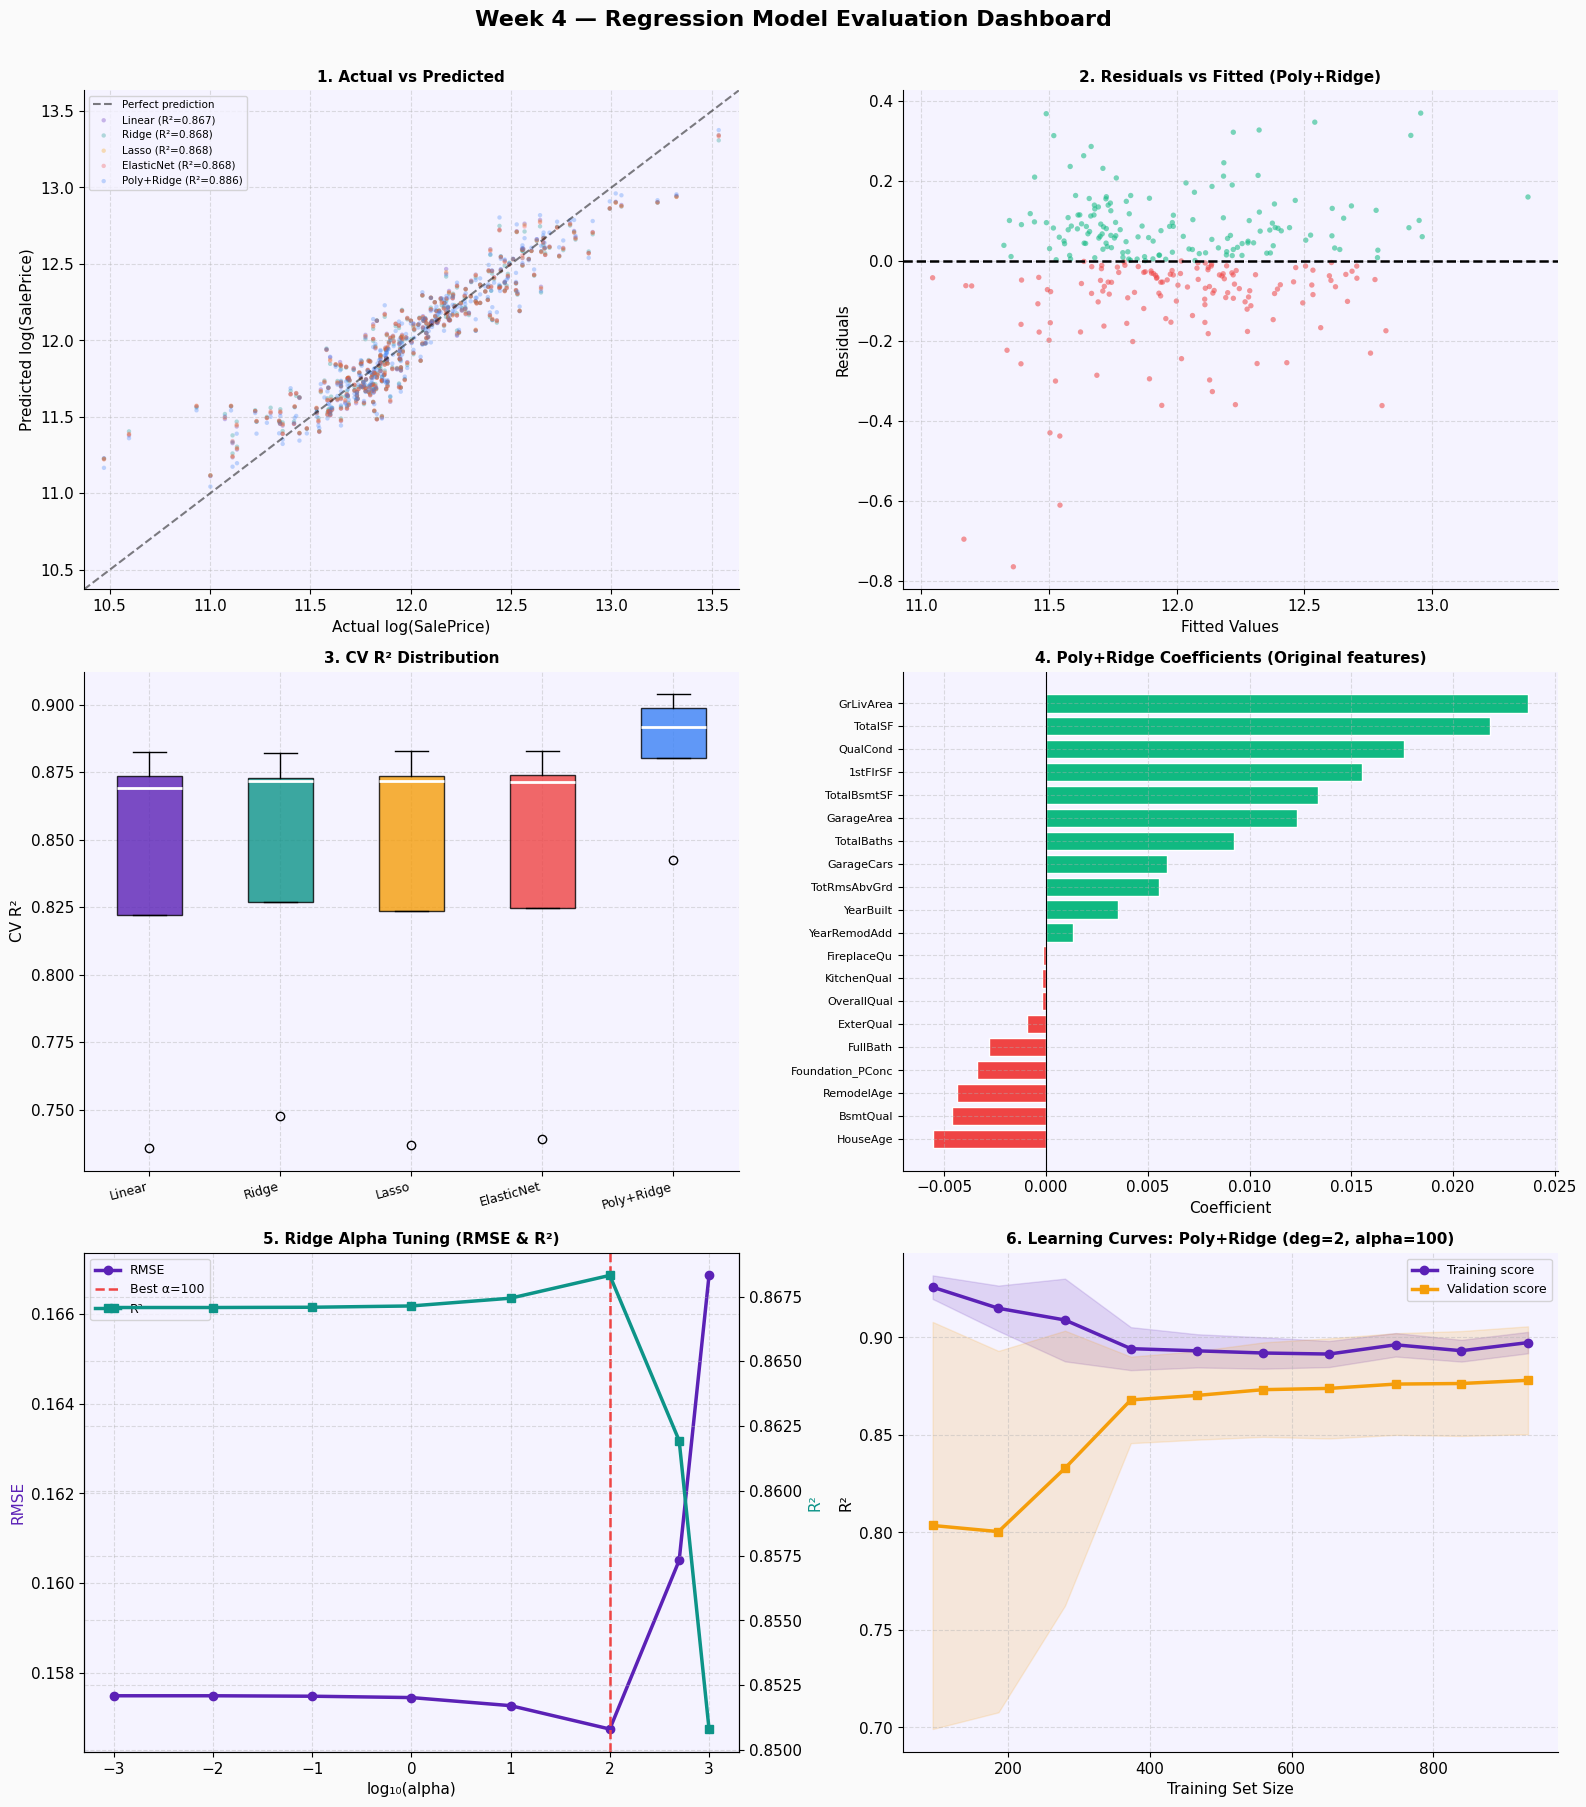

Saved: week4_dashboard.png


In [17]:
# Step 16: Complete 6-Chart Model Evaluation Dashboard
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle('Week 4 — Regression Model Evaluation Dashboard',
             fontsize=16, fontweight='bold', y=1.002)
fig.patch.set_facecolor('#FAFAFA')

y_arr = np.array(y_test)

# Chart 1
ax = axes[0, 0]
lims = [y_arr.min() - 0.1, y_arr.max() + 0.1]
ax.plot(lims, lims, 'k--', linewidth=1.5, alpha=0.5, label='Perfect prediction')
for (name, preds), color in zip(model_preds.items(), palette5):
    r2 = r2_score(y_arr, preds)
    ax.scatter(y_arr, preds, alpha=0.3, s=10, color=color,
               edgecolors='none', label=f'{name} (R²={r2:.3f})')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_title('1. Actual vs Predicted', fontweight='bold', fontsize=11)
ax.set_xlabel('Actual log(SalePrice)'); ax.set_ylabel('Predicted log(SalePrice)')
ax.legend(fontsize=7.5, loc='upper left')
ax.spines[['top', 'right']].set_visible(False)

# Chart 2
residuals_pr   = y_arr - np.array(y_pred_pr)
fitted_vals_pr = np.array(y_pred_pr)

ax = axes[0, 1]
res_c = ['#10B981' if r >= 0 else '#EF4444' for r in residuals_pr]
ax.scatter(fitted_vals_pr, residuals_pr, c=res_c, alpha=0.55, s=15, edgecolors='none')
ax.axhline(0, color='black', linewidth=1.8, linestyle='--')
ax.set_title('2. Residuals vs Fitted (Poly+Ridge)', fontweight='bold', fontsize=11)
ax.set_xlabel('Fitted Values'); ax.set_ylabel('Residuals')
ax.spines[['top', 'right']].set_visible(False)

# Chart 3
ax = axes[1, 0]
bp = ax.boxplot([cv_r2_scores[m] for m in cv_models], patch_artist=True,
                labels=list(cv_models.keys()),
                medianprops=dict(color='white', linewidth=2))
for patch, color in zip(bp['boxes'], palette5):
    patch.set_facecolor(color); patch.set_alpha(0.8)
ax.set_title('3. CV R² Distribution', fontweight='bold', fontsize=11)
ax.set_ylabel('CV R²')
plt.setp(ax.get_xticklabels(), rotation=15, ha='right', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

# Chart 4
ax = axes[1, 1]
pr_named_coefs = pd.Series(
    best_pipeline.named_steps['ridge'].coef_,
    index=best_pipeline.named_steps['poly'].get_feature_names_out(X_train.columns)
)

original_terms = [f for f in pr_named_coefs.index if ' ' not in f and '^' not in f]
pr_linear_coefs = pr_named_coefs[original_terms].sort_values()
bc4 = ['#10B981' if v >= 0 else '#EF4444' for v in pr_linear_coefs]
ax.barh(pr_linear_coefs.index, pr_linear_coefs.values, color=bc4, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('4. Poly+Ridge Coefficients (Original features)',
             fontweight='bold', fontsize=11)
ax.set_xlabel('Coefficient')
ax.tick_params(axis='y', labelsize=8)
ax.spines[['top', 'right']].set_visible(False)

# Chart 5
ax5a = axes[2, 0]
ax5b = ax5a.twinx()
log_a = np.log10(ridge_df['Alpha'])
ax5a.plot(log_a, ridge_df['RMSE'], color='#5B21B6', marker='o', linewidth=2.5, label='RMSE')
ax5b.plot(log_a, ridge_df['R2'],   color='#0D9488', marker='s', linewidth=2.5, label='R²')
ax5a.axvline(np.log10(best_ridge_alpha), color='#EF4444',
             linestyle='--', linewidth=1.8, label=f'Best α={best_ridge_alpha}')
ax5a.set_title('5. Ridge Alpha Tuning (RMSE & R²)', fontweight='bold', fontsize=11)
ax5a.set_xlabel('log₁₀(alpha)')
ax5a.set_ylabel('RMSE', color='#5B21B6')
ax5b.set_ylabel('R²',   color='#0D9488')
lines1, lab1 = ax5a.get_legend_handles_labels()
lines2, lab2 = ax5b.get_legend_handles_labels()
ax5a.legend(lines1 + lines2, lab1 + lab2, fontsize=9)
ax5a.spines[['top']].set_visible(False)

# Chart 6
ax = axes[2, 1]
lc_pipe_pr = Pipeline([
    ('poly',   PolynomialFeatures(degree=best_poly_degree, include_bias=False)),
    ('scaler', StandardScaler()),
    ('ridge',  Ridge(alpha=best_pr_alpha))
])
ts, tr_sc6, vl_sc6 = learning_curve(
    lc_pipe_pr, X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5, scoring='r2', n_jobs=-1
)
tr_m6, tr_s6 = tr_sc6.mean(1), tr_sc6.std(1)
vl_m6, vl_s6 = vl_sc6.mean(1), vl_sc6.std(1)
ax.plot(ts, tr_m6, color='#5B21B6', linewidth=2.5, marker='o', label='Training score')
ax.fill_between(ts, tr_m6 - tr_s6, tr_m6 + tr_s6, alpha=0.15, color='#5B21B6')
ax.plot(ts, vl_m6, color='#F59E0B', linewidth=2.5, marker='s', label='Validation score')
ax.fill_between(ts, vl_m6 - vl_s6, vl_m6 + vl_s6, alpha=0.15, color='#F59E0B')
ax.set_title(f'6. Learning Curves: Poly+Ridge (deg={best_poly_degree}, alpha={best_pr_alpha})',
             fontweight='bold', fontsize=11)
ax.set_xlabel('Training Set Size'); ax.set_ylabel('R²')
ax.legend(fontsize=9); ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.998])
plt.savefig('week4_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: week4_dashboard.png')

Prediction DataFrame (first 10 rows)


,index,actual_price,predicted_price,error,pct_error
0,892,154500.0,145809.0,-8691.0,-5.62
1,1105,325000.0,329324.0,4324.0,1.33
2,413,115000.0,120775.0,5775.0,5.02
3,522,159000.0,169762.0,10762.0,6.77
4,1036,315500.0,329526.0,14026.0,4.45
5,614,75500.0,88489.0,12989.0,17.20
6,218,311500.0,224733.0,-86767.0,-27.85
7,1160,146000.0,153981.0,7981.0,5.47
8,649,84500.0,88665.0,4165.0,4.93
9,887,135500.0,134918.0,-582.0,-0.43


10 Largest Prediction Errors (by absolute $)


,index,actual_price,predicted_price,error,pct_error
74,898,611657.0,423043.0,-188614.0,-30.84
168,1046,556581.0,406982.0,-149599.0,-26.88
260,774,395000.0,279439.0,-115561.0,-29.26
139,691,755000.0,643815.0,-111185.0,-14.73
43,581,253293.0,363607.0,110314.0,43.55
6,218,311500.0,224733.0,-86767.0,-27.85
200,451,280000.0,203126.0,-76874.0,-27.46
167,261,276000.0,347560.0,71560.0,25.93
278,588,143000.0,204800.0,61800.0,43.22
38,1032,310000.0,369172.0,59172.0,19.09



Model saved: week4_best_model.pkl  (Poly+Ridge)
Verification - loaded model prediction on row 0: $145,809
Actual price on row 0:                           $154,500


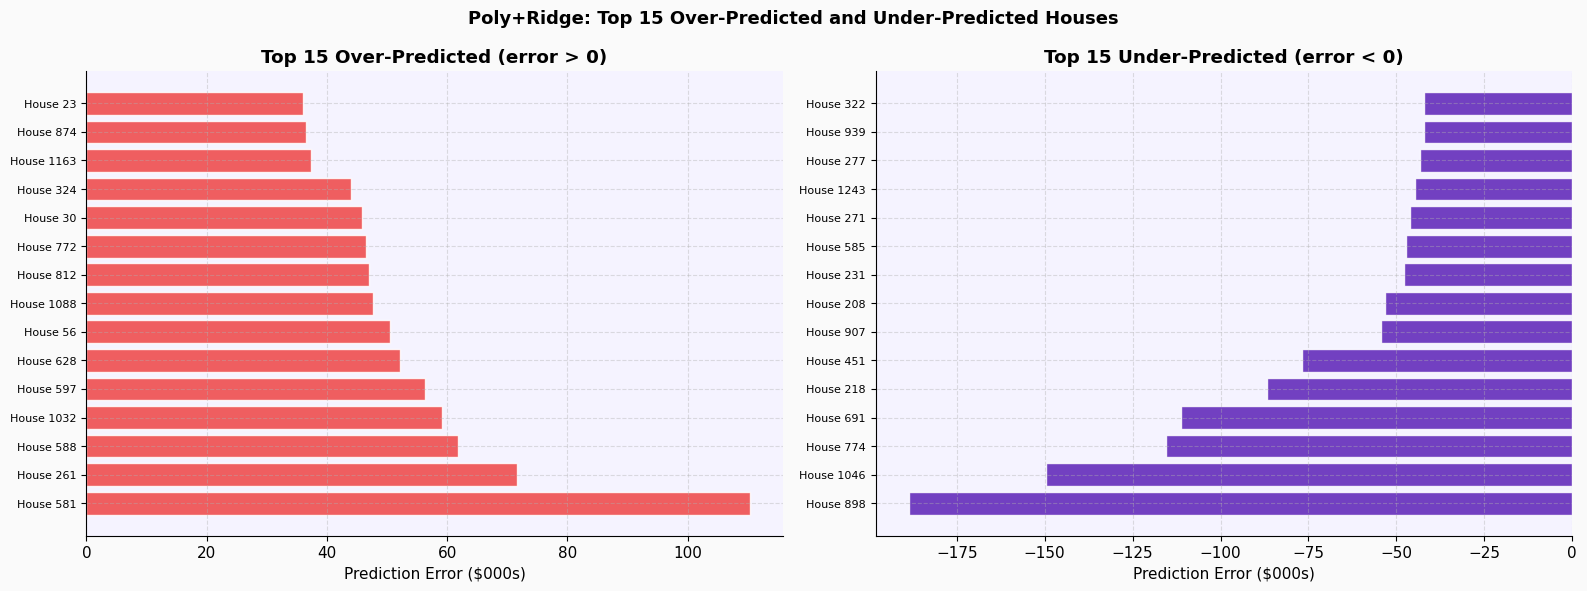

In [19]:
# Step 17: Generate Predictions on Test Set & Save Model

y_pred_log_pr    = best_pipeline.predict(X_test)
y_pred_dollar_pr = np.expm1(y_pred_log_pr)
y_actual_dollar  = np.expm1(np.array(y_test))

pred_df = pd.DataFrame({
    'index':           X_test.index,
    'actual_price':    y_actual_dollar.round(0),
    'predicted_price': y_pred_dollar_pr.round(0),
    'error':           (y_pred_dollar_pr - y_actual_dollar).round(0),
    'pct_error':       ((y_pred_dollar_pr - y_actual_dollar) / y_actual_dollar * 100).round(2)
}).reset_index(drop=True)

print('='*60)
print('Prediction DataFrame (first 10 rows)')
display(pred_df.head(10))

print('='*60)
print('10 Largest Prediction Errors (by absolute $)')
largest_errors = pred_df.reindex(
    pred_df['error'].abs().sort_values(ascending=False).index
).head(10)
display(largest_errors)

joblib.dump(best_pipeline, 'week4_best_model.pkl')
print('\nModel saved: week4_best_model.pkl  (Poly+Ridge)')

loaded_model = joblib.load('week4_best_model.pkl')
sample_pred  = loaded_model.predict(X_test.iloc[:1])
print(f'Verification - loaded model prediction on row 0: ${np.expm1(sample_pred[0]):,.0f}')
print(f'Actual price on row 0:                           ${y_actual_dollar[0]:,.0f}')

pred_df['abs_error'] = pred_df['error'].abs()
over_pred  = pred_df[pred_df['error'] > 0].nlargest(15, 'abs_error')
under_pred = pred_df[pred_df['error'] < 0].nlargest(15, 'abs_error')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Poly+Ridge: Top 15 Over-Predicted and Under-Predicted Houses',
             fontsize=13, fontweight='bold')

ax = axes[0]
ax.barh(range(len(over_pred)), over_pred['error'] / 1000,
        color='#EF4444', edgecolor='white', alpha=0.85)
ax.set_yticks(range(len(over_pred)))
ax.set_yticklabels([f'House {i}' for i in over_pred['index']], fontsize=8)
ax.set_title('Top 15 Over-Predicted (error > 0)', fontweight='bold')
ax.set_xlabel('Prediction Error ($000s)')
ax.spines[['top', 'right']].set_visible(False)

ax = axes[1]
ax.barh(range(len(under_pred)), under_pred['error'] / 1000,
        color='#5B21B6', edgecolor='white', alpha=0.85)
ax.set_yticks(range(len(under_pred)))
ax.set_yticklabels([f'House {i}' for i in under_pred['index']], fontsize=8)
ax.set_title('Top 15 Under-Predicted (error < 0)', fontweight='bold')
ax.set_xlabel('Prediction Error ($000s)')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

### Step 17 Analysis
The largest prediction errors cluster among luxury properties at the top of the price distribution — houses where `SalePrice` exceeds $400,000. This is consistent with the residual diagnostics from Step 12: variance increases at the high end of fitted values, reflecting the intrinsically higher pricing uncertainty of rare, high-value properties whose prices are influenced by bespoke features (unique architecture, premium finishes, location micro-factors) that the model's 20 standardised features cannot capture. Under-predicted houses share a similar pattern — properties that sold well above what their structural attributes imply, often driven by bidding competition or neighbourhood factors not represented in the feature set.

# **Digitech Offerings AI/ML Internship Week 04 - Report**

# **1. Executive Summary**

In this project, five regression-based machine learning models were trained and evaluated on the House Prices dataset to predict residential property sale prices. The models included Linear Regression, Ridge Regression, Lasso Regression, ElasticNet Regression, and a Polynomial + Ridge Pipeline model. The dataset was first preprocessed using feature engineering techniques such as missing value handling, quality encoding, frequency encoding, one-hot encoding, feature scaling, and logarithmic transformation of the target variable to reduce skewness and improve model stability.

Among all evaluated models, the Polynomial + Ridge Pipeline achieved the strongest overall performance. The model produced a test R² score of 0.8865, indicating that approximately 88.65% of the variance in housing prices was successfully explained by the model. It also achieved the lowest RMSE value of 0.1455 on the log-transformed scale, corresponding to an approximate dollar RMSE of $27,760 after inverse transformation. These results demonstrated that combining polynomial feature expansion with Ridge regularization allowed the model to capture non-linear relationships while simultaneously controlling overfitting.

The overall analysis showed that regularization techniques significantly improved model generalization, especially when dealing with correlated and high-dimensional feature spaces. Residual diagnostics, cross-validation, and learning curves further confirmed that the final model generalized well to unseen data and maintained a balanced bias-variance tradeoff.

# **2. Feature Engineering Impact**

Feature engineering from Week 3 played a critical role in improving the predictive performance of all regression models. The original dataset contained missing values, categorical variables, ordinal quality features, skewed distributions, and inconsistent scales, all of which negatively affect linear models if left untreated. By applying systematic preprocessing techniques, the dataset became significantly more suitable for machine learning.

One of the most impactful transformations was the encoding of ordinal quality-related variables such as overall quality, kitchen quality, and exterior condition using numerical quality mappings (Ex=5, Gd=4, TA=3, Fa=2, Po=1). This preserved the natural ranking information that would otherwise be lost with standard one-hot encoding. Frequency encoding of the Neighborhood feature also helped reduce dimensionality while still preserving useful location-based information.

The logarithmic transformation of the target variable SalePrice was another major improvement. Before transformation, the target distribution was heavily right-skewed, which violated assumptions of linear regression and increased sensitivity to extreme prices. Applying np.log1p() reduced skewness and stabilized variance, allowing models to learn more effectively.

Correlation analysis revealed that features such as 'OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', and 'YearBuilt' had the strongest influence on price prediction. These features consistently appeared among the most influential coefficients across multiple models. Scaling with StandardScaler further ensured that all features contributed proportionally during optimization and regularization.

Overall, the preprocessing and feature engineering pipeline substantially improved model accuracy, reduced instability, and enabled the regularized models to perform effectively.



# **3. Model-by-Model Analysis**

**Linear Regression**: Linear Regression served as the baseline model for the project. It achieved a test R² score of 0.8671, which already indicated strong predictive capability. The training and testing scores were relatively close, suggesting that the model generalized reasonably well and did not suffer from severe overfitting. However, because Linear Regression assumes purely linear relationships between features and the target variable, it struggled to fully capture complex interactions within the housing dataset. Coefficient analysis revealed that features such as overall quality and living area had the strongest positive influence on predicted prices. While the model was highly interpretable, its inability to model non-linear relationships limited its maximum achievable accuracy.

**Ridge Regression**: Ridge Regression improved upon Linear Regression by introducing L2 regularization, which penalized excessively large coefficients. The best Ridge model achieved a test R² score of 0.8683, slightly outperforming the baseline model while also producing more stable coefficients. Through alpha tuning using GridSearchCV, the optimal regularization strength balanced bias and variance effectively. The regularization term reduced sensitivity to multicollinearity among features, which is common in housing datasets where many variables are correlated. Ridge Regression produced smoother coefficient distributions and demonstrated better generalization during cross-validation. It also reduced the risk of overfitting without eliminating useful features entirely.

**Lasso Regression**: Lasso Regression introduced L1 regularization, which not only shrank coefficients but also forced several coefficients to become exactly zero. This effectively performed automatic feature selection. The model achieved slightly lower predictive performance compared to Ridge Regression, but it significantly improved interpretability by simplifying the feature space. Several weak or redundant features were eliminated during optimization, confirming that not all variables contributed meaningfully to house price prediction. The model demonstrated the tradeoff between interpretability and predictive accuracy: while simpler and more explainable, it sacrificed some predictive power compared to Ridge and Poly+Ridge models.

**ElasticNet Regression**: ElasticNet combined both L1 and L2 penalties, attempting to benefit from feature selection while also handling correlated features more effectively. Through tuning of alpha and l1_ratio parameters, ElasticNet achieved competitive performance close to Ridge Regression. The model proved particularly useful because the housing dataset contained many correlated numerical variables. Unlike Lasso, which may arbitrarily eliminate correlated features, ElasticNet retained groups of related variables while still applying regularization. The heatmap visualization demonstrated how different alpha and l1_ratio combinations affected model performance, highlighting the importance of hyperparameter tuning in machine learning workflows.

**Polynomial + Ridge Pipeline**: The Polynomial + Ridge Pipeline achieved the best overall performance with a test R² score of 0.8865 and RMSE of 0.1455. Polynomial feature expansion allowed the model to learn non-linear interactions between variables, while Ridge regularization prevented the resulting high-dimensional feature space from overfitting. Without regularization, higher-degree polynomial models quickly showed signs of overfitting, with training R² increasing dramatically while test R² stagnated or decreased. By integrating Ridge Regression inside the pipeline, the model maintained strong generalization despite the expanded feature set. The pipeline architecture also prevented data leakage by ensuring that scaling and polynomial transformations were applied correctly inside cross-validation folds. This model ultimately provided the best balance between complexity, predictive accuracy, and generalization performance.

# **4. Regularization Insights**

Regularization proved essential throughout this project, especially because the dataset contained many correlated and high-dimensional features. Ridge Regression, Lasso Regression, and ElasticNet each addressed overfitting differently from both mathematical and practical perspectives.

Ridge Regression uses an L2 penalty term that shrinks coefficients toward zero but never removes them completely. This was especially useful for the housing dataset because many variables contributed partially to price prediction. Ridge stabilized coefficient values and reduced variance without sacrificing important information.

Lasso Regression uses an L1 penalty term, which drives some coefficients exactly to zero. This effectively performs automatic feature selection. Features with weak predictive value or redundancy were removed entirely, simplifying the model. The eliminated features generally included less informative categorical indicators and low-correlation variables, which aligned with intuition from the correlation analysis conducted during preprocessing.

ElasticNet combined both approaches using the l1_ratio parameter. This allowed the model to retain the stability of Ridge while still benefiting from the sparsity introduced by Lasso. In practice, ElasticNet handled correlated features better than pure Lasso, since it did not arbitrarily discard strongly related variables.

Overall, the experiments demonstrated that regularization is not only about preventing overfitting but also about improving stability, interpretability, and generalization. The project clearly showed how increasing regularization strength simplified models while excessive regularization eventually reduced predictive accuracy.

# **5. Residual Analysis Findings**

Residual analysis provided valuable insight into the quality and assumptions of the final model. The residual vs fitted plot showed that residuals were distributed relatively randomly around zero, indicating that the model successfully captured most major patterns within the data. No strong systematic structures or curves were observed, which suggested that the linearity assumptions were reasonably satisfied after polynomial expansion.

The residual histogram appeared approximately bell-shaped, while the Q-Q plot showed that most residuals followed the diagonal reference line with only moderate deviations at the tails. This indicated that the residuals were close to normally distributed, although some outliers remained due to extreme housing prices.

The Scale-Location plot demonstrated relatively stable variance across prediction ranges, suggesting acceptable homoscedasticity. Additionally, the Shapiro-Wilk test produced a p-value indicating that the residual distribution was reasonably close to normal for practical modeling purposes.

Overall, the diagnostic plots confirmed that the final model generalized effectively and satisfied the key assumptions required for regression analysis. While some minor deviations remained, the residual behavior strongly supported the reliability of the final predictions.

# **6. Best Model Recommendation**

Based on all experimental results, the Polynomial + Ridge Pipeline is the recommended model for deployment. It consistently outperformed the other models across evaluation metrics, achieving the highest test R² score of 0.8865 and the lowest RMSE value among all tested approaches.

From a technical perspective, the model succeeded because it combined the strengths of both polynomial feature engineering and Ridge regularization. Polynomial expansion enabled the model to capture complex non-linear relationships between housing attributes and sale prices, while Ridge regularization controlled coefficient growth and reduced overfitting. This combination produced strong predictive power while maintaining stable generalization across cross-validation folds.

From a business perspective, the model offers practical value because accurate house price predictions are critical for real estate valuation, investment analysis, mortgage estimation, and market forecasting. Lower prediction error directly translates into more reliable pricing decisions and reduced financial risk.

Additionally, the pipeline structure makes deployment easier because preprocessing, scaling, feature expansion, and prediction are packaged into a single reusable object. This improves maintainability and reduces the likelihood of preprocessing inconsistencies during real-world use.

**7. Reflection**

One of the most challenging concepts in this project was understanding the bias-variance tradeoff and how regularization affects model complexity. Initially, it seemed counterintuitive that intentionally constraining a model could improve predictive performance. However, through experimentation with Ridge, Lasso, and ElasticNet, it became clear that preventing excessive complexity often leads to better generalization on unseen data.

Another difficult aspect was interpreting diagnostic plots and learning curves. Understanding how residual patterns relate to model assumptions required careful analysis and multiple iterations of experimentation. The coefficient path visualizations were especially insightful because they clearly showed how increasing regularization gradually shrinks or removes feature influence.

The biggest surprise in the project was how effective the Polynomial + Ridge combination became compared to plain Linear Regression. Polynomial expansion alone quickly caused overfitting, but regularization stabilized the model and transformed it into the strongest performer overall.

If this project were extended further, additional ensemble-based regression methods such as Random Forest Regressor, XGBoost, or Gradient Boosting could be explored. These models may capture even more complex interactions and potentially achieve higher predictive accuracy than linear-based approaches.